# 1. Preparation des donnees

## 1. Charger les jeux de donnees suivants :

In [63]:
from google.colab import files
uploaded = files.upload()
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Saving emotion-labels-test.csv to emotion-labels-test (3).csv
Saving emotion-labels-train.csv to emotion-labels-train (3).csv
Saving emotion-labels-val.csv to emotion-labels-val (3).csv
User uploaded file "emotion-labels-test (3).csv" with length 324365 bytes
User uploaded file "emotion-labels-train (3).csv" with length 372586 bytes
User uploaded file "emotion-labels-val (3).csv" with length 36442 bytes


Ce code permet à l'utilisateur de télécharger des fichiers dans l'environnement d'exécution Google Colab.

In [12]:
train_data = pd.read_csv('emotion-labels-train.csv')
test_data = pd.read_csv('emotion-labels-test.csv')
val_data = pd.read_csv('emotion-labels-val.csv')

Ce code charge des données CSV (train, test, validation) dans des DataFrames pandas.


Ces lignes permettent de visualiser les données

In [13]:
train_data

,text,label
0,Just got back from seeing @GaryDelaney in Burs...,joy
1,Oh dear an evening of absolute hilarity I don'...,joy
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy
4,I feel so blessed to work with the family that...,joy
...,...,...
3608,@VivienLloyd Thank you so much! Just home - st...,sadness
3609,Just put the winter duvet on ☃️❄️🌬☔️,sadness
3610,@SilkInSide @TommyJoeRatliff that's so pretty!...,sadness
3611,@BluesfestByron second artist announcement loo...,sadness


In [14]:
test_data

,text,label
0,You must be knowing #blithe means (adj.) Happ...,joy
1,Old saying 'A #smile shared is one gained for ...,joy
2,Bridget Jones' Baby was bloody hilarious 😅 #Br...,joy
3,@Elaminova sparkling water makes your life spa...,joy
4,I'm tired of everybody telling me to chill out...,joy
...,...,...
3137,Why does Candice constantly pout #GBBO 💄😒,sadness
3138,"@redBus_in #unhappy with #redbus CC, when I ta...",sadness
3139,"@AceOperative789 no pull him afew weeks ago, s...",sadness
3140,I'm buying art supplies and I'm debating how s...,sadness


In [15]:
val_data

,text,label
0,"@theclobra lol I thought maybe, couldn't decid...",joy
1,Nawaz Sharif is getting more funnier than @kap...,joy
2,Nawaz Sharif is getting more funnier than @kap...,joy
3,@tomderivan73 😁...I'll just people watch and e...,joy
4,I love my family so much #lucky #grateful #sma...,joy
...,...,...
342,Common app just randomly logged me out as I wa...,sadness
343,"I'd rather laugh with the rarest genius, in be...",sadness
344,If you #invest in my new #film I will stop ask...,sadness
345,"Just watched Django Unchained, Other people ma...",sadness


## 2. Fusionner les ensembles d’entraınement, de test et de validation en un seul DataFrame pour faciliter le traitement global des donnees.

In [16]:
all_data = pd.concat([train_data, test_data, val_data], ignore_index=True)

concatène ces trois DataFrames en un seul pour faciliter le prétraitement, puis montre le résultat

In [64]:
all_data

,text,label,text_clean
0,Just got back from seeing @GaryDelaney in Burs...,joy,just got back from seeing in burslem amazing ...
1,Oh dear an evening of absolute hilarity I don'...,joy,oh dear an evening of absolute hilarity i dont...
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy,been waiting all week for this game cheer friday
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy,thank you so much gloria youre so sweet and th...
4,I feel so blessed to work with the family that...,joy,i feel so blessed to work with the family that...
...,...,...,...
7097,Common app just randomly logged me out as I wa...,sadness,common app just randomly logged me out as i wa...
7098,"I'd rather laugh with the rarest genius, in be...",sadness,id rather laugh with the rarest genius in beau...
7099,If you #invest in my new #film I will stop ask...,sadness,if you invest in my new film i will stop askin...
7100,"Just watched Django Unchained, Other people ma...",sadness,just watched django unchained other people may...


## 3. Nettoyer les textes en supprimant les elements non pertinents

In [18]:
all_data['text_clean'] = all_data['text'].str.replace(r'@\w+', '', regex=True)
all_data['text_clean'] = all_data['text_clean'].str.replace(r'http\S+|www\S+|https\S+', '', regex=True)
all_data['text_clean'] = all_data['text_clean'].str.replace(r'[^\w\s]', '', regex=True)
all_data['text_clean'] = all_data['text_clean'].str.strip().str.lower()


nettoie le texte en supprimant les mentions (@), les URLs et la ponctuation, et en mettant tout en minuscules puis visualisation

In [67]:
all_data

,text,label,text_clean
0,Just got back from seeing @GaryDelaney in Burs...,joy,just got back from seeing in burslem amazing ...
1,Oh dear an evening of absolute hilarity I don'...,joy,oh dear an evening of absolute hilarity i dont...
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy,been waiting all week for this game cheer friday
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy,thank you so much gloria youre so sweet and th...
4,I feel so blessed to work with the family that...,joy,i feel so blessed to work with the family that...
...,...,...,...
7097,Common app just randomly logged me out as I wa...,sadness,common app just randomly logged me out as i wa...
7098,"I'd rather laugh with the rarest genius, in be...",sadness,id rather laugh with the rarest genius in beau...
7099,If you #invest in my new #film I will stop ask...,sadness,if you invest in my new film i will stop askin...
7100,"Just watched Django Unchained, Other people ma...",sadness,just watched django unchained other people may...


## 4. Visualiser la repartition des emotions dans les donnees pour verifier leur equilibre

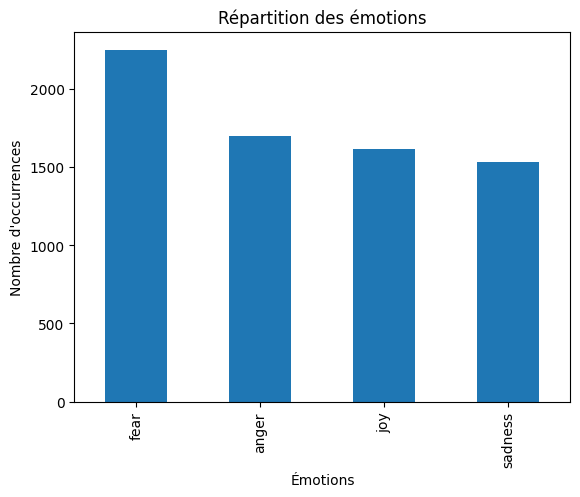

In [20]:
import matplotlib.pyplot as plt

all_data['label'].value_counts().plot(kind='bar')
plt.title("Répartition des émotions")
plt.xlabel("Émotions")
plt.ylabel("Nombre d'occurrences")
plt.show()

le code crée un graphique en barres qui visualise la répartition des différentes émotions présentes dans le jeu de données combiné. Ce graphique montre le nombre d'occurrences de chaque émotion dans la colonne 'label' du DataFrame `all_data`.  On peut observer que les données ne sont pas trop équilibrées.

# 2. Analyse exploratoire des donnees

## 1. Realiser une analyse exploratoire pour comprendre la repartition des labels.

In [21]:
label_counts = all_data['label'].value_counts()
print(label_counts)

print("Nombre total d'exemples :", len(all_data))
print("Nombre de classes uniques :", all_data['label'].nunique())
print("Classe avec le plus grand nombre d'exemples :", label_counts.idxmax())
print("Classe avec le plus petit nombre d'exemples :", label_counts.idxmin())


label
fear       2252
anger      1701
joy        1616
sadness    1533
Name: count, dtype: int64
Nombre total d'exemples : 7102
Nombre de classes uniques : 4
Classe avec le plus grand nombre d'exemples : fear
Classe avec le plus petit nombre d'exemples : sadness


Ce code affiche des statistiques sur les labels (nombre total d'exemples, nombre de classes uniques, classe majoritaire et minoritaire).


label
fear       31.709378
anger      23.951000
joy        22.754154
sadness    21.585469
Name: proportion, dtype: float64


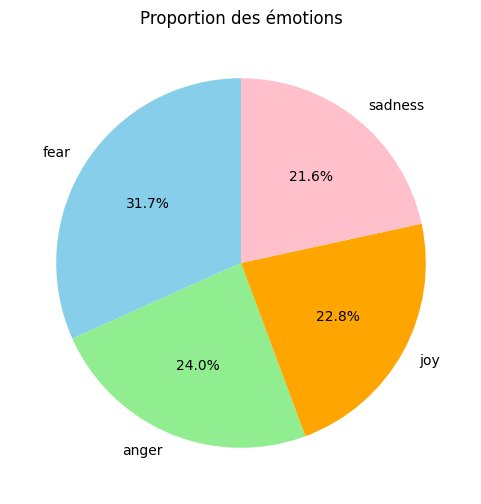

In [23]:
label_proportions = all_data['label'].value_counts(normalize=True) * 100
print(label_proportions)

label_proportions.plot(kind='pie', autopct='%1.1f%%', startangle=90, figsize=(6, 6), colors=['skyblue', 'lightgreen', 'orange', 'pink'])
plt.title("Proportion des émotions")
plt.ylabel("")
plt.show()


visualise la distribution des émotions

## 2. Reequilibrer les classes si necessaire en effectuant un echantillonnage

In [22]:
from sklearn.utils import resample

target_count = all_data['label'].value_counts().max()

balanced_data = pd.concat([
    resample(group, replace=True, n_samples=target_count, random_state=42)
    if len(group) < target_count else group
    for _, group in all_data.groupby('label')
])

print(balanced_data['label'].value_counts())


label
anger      2252
fear       2252
joy        2252
sadness    2252
Name: count, dtype: int64


Les classes sont rééquilibrées par sur-échantillonnage (augmentation du nombre d'exemples des classes minoritaires pour atteindre le nombre d'exemples de la classe majoritaire), afin de préparer les données pour un modèle d'apprentissage automatique

### Un graphique montrant la distribution des emotions apres reequilibrage

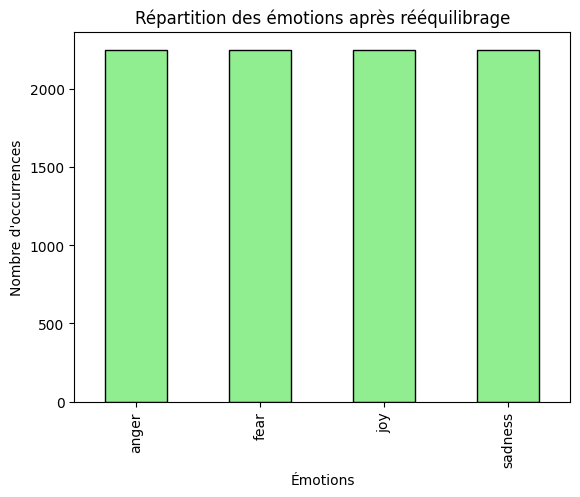

In [24]:
balanced_data['label'].value_counts().plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title("Répartition des émotions après rééquilibrage")
plt.xlabel("Émotions")
plt.ylabel("Nombre d'occurrences")
plt.show()


Visualisation des emotions rééquilibrées

# 3. Preparation des donnees pour le modele

## 1. Encoder les labels en entiers (exemple : 0 pour colere, 1 pour peur, etc.) a l’aide d’un LabelEncoder

In [25]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
balanced_data['label_encoded'] = label_encoder.fit_transform(balanced_data['label'])

les labels émotionnels sont encodés numériquement

Visualisation des nouvelles données

In [68]:
balanced_data

,text,label,text_clean,label_encoded
5591,@paulsherard @margarethaynie wow I just realiz...,anger,wow i just realized how much of a sexist pig i...,0
5924,@RossKemp watching on +1. I would have been st...,anger,watching on 1 i would have been straight out o...,0
5325,@spamvicious I've just found out it's Candice ...,anger,ive just found out its candice and not candace...,0
5759,How hard is it to get in touch with @bt_uk! On...,anger,how hard is it to get in touch with one simpl...,0
5595,13 hour @bus rides make me #angry #sorry,anger,13 hour rides make me angry sorry,0
...,...,...,...,...
3131,Shoutout to the drunk man on the bus who pisse...,sadness,shoutout to the drunk man on the bus who pisse...,3
3562,"@AMB4JC @drtonyevans It's our job, the job of ...",sadness,its our job the job of people who r still sane...,3
7089,Chalk dance notation entree manchester inasmuc...,sadness,chalk dance notation entree manchester inasmuc...,3
3117,"Two blankets, a hoody, and still no Eternal Su...",sadness,two blankets a hoody and still no eternal suns...,3


## 2. Diviser les donnees en ensembles d’entraınement (80%), de validation (10%), et de test (10%).

In [27]:
from sklearn.model_selection import train_test_split

train, temp = train_test_split(balanced_data, test_size=0.2, random_state=42)
val, test = train_test_split(temp, test_size=0.5, random_state=42)

Division des données

In [28]:
train

,text,label,text_clean,label_encoded
665,@johnwintertweet dudes who wanna play some bas...,joy,dudes who wanna play some bass but not buy a b...,2
3070,Cause fail or pass I refuse to be sober,sadness,cause fail or pass i refuse to be sober,3
3424,@KhoroshiySoldat --prepared.\n\n'Not as far as...,sadness,preparednnnot as far as i know was her dull re...,3
4442,@ddcl2519 @ABC not nice. Wishing harm on anot...,fear,not nice wishing harm on another human being ...,1
3862,.@Travelanswerman: The possibilities R endless...,joy,the possibilities r endless becca when u unplu...,2
...,...,...,...,...
754,"@TheDemocrats dilemma, blaiming everything on ...",joy,dilemma blaiming everything on the bushes but ...,2
4235,@T_newhouse13 as granny would say I don't know...,joy,as granny would say i dont know how to chirp,2
74,A #smile brightens your day and the day of eve...,joy,a smile brightens your day and the day of ever...,2
1979,How is it suppose to work if you do that? Wtf ...,anger,how is it suppose to work if you do that wtf d...,0


In [29]:
temp

,text,label,text_clean,label_encoded
3525,tones - \n: 1/2 of my favourite chris pine sta...,sadness,tones n 12 of my favourite chris pine stans i...,3
4172,- its lit having a class with you!!! Your s...,joy,its lit having a class with you your such a gr...,2
6497,There will be no #gaming video today. An old f...,sadness,there will be no gaming video today an old fri...,3
1702,How I Murdered Your Mother #SpookyTv,fear,how i murdered your mother spookytv,1
2732,"Well, the lines for Sweden's goals sure sting.",anger,well the lines for swedens goals sure sting,0
...,...,...,...,...
2349,@HebertofNH any time a man who got paid to thr...,anger,any time a man who got paid to throw temper ta...,0
3412,In serious need of a nap,sadness,in serious need of a nap,3
556,Riggs dumb ass hell lolol #LethalWeapon,joy,riggs dumb ass hell lolol lethalweapon,2
514,#Arts create richness &amp; liveliness in our ...,joy,arts create richness amp liveliness in our soc...,2


In [30]:
val

,text,label,text_clean,label_encoded
403,@u4uzoma Boss I see you as someone that is jov...,joy,boss i see you as someone that is jovial and f...,2
5980,"Don't be offended,\nI'm just doing something t...",anger,dont be offendednim just doing something thatn...,0
1295,@Mc_Cabe_Conor This is it. The complete illite...,fear,this is it the complete illiteracy around the ...,1
4689,@lhbrown1990 @Jimcummingsacme I'm afraid to look!,fear,im afraid to look,1
6065,Who allowed Pereira to start taking all the se...,anger,who allowed pereira to start taking all the se...,0
...,...,...,...,...
600,Lil reminder that my private account is a deli...,joy,lil reminder that my private account is a deli...,2
3552,#RiceFODays now I am Alex Butler's class on fi...,sadness,ricefodays now i am alex butlers class on fina...,3
5715,"your outrage (your tweets, your jokes, your at...",anger,your outrage your tweets your jokes your atten...,0
5650,@johnmerro1 @Liberobility still bitter about l...,anger,still bitter about last night lads,0


In [31]:
test

,text,label,text_clean,label_encoded
4086,Coworker: 'That happened to a friend of mine o...,joy,coworker that happened to a friend of mine onc...,2
81,@morgannbroom yes ❤️❤️ &amp; cheering homecomi...,joy,yes amp cheering homecoming game,2
5903,tbh amy i don't know why you need to sort your...,anger,tbh amy i dont know why you need to sort your ...,0
2827,Depression sucks! #depression,sadness,depression sucks depression,3
5290,Insomniacs can't get sleep cuz they are too gu...,fear,insomniacs cant get sleep cuz they are too gui...,1
...,...,...,...,...
5973,You boys dint know the game am I the game... l...,anger,you boys dint know the game am i the game life...,0
213,All in all a pleasing night down The Lane . ....,joy,all in all a pleasing night down the lane ...,2
3526,"Amateurs sit and wait for inspiration, the res...",sadness,amateurs sit and wait for inspiration the rest...,3
3186,@pandaflo22 We are sadden by this because we a...,sadness,we are sadden by this because we always strive...,3


## 3. Convertir ces ensembles en objets DatasetDict pour le traitement avec Hugging Face

## 4. Structurer les ensembles d’entraınement et de test dans des DataFrames simplifies contenant uniquement les colonnes necessaires (label et text).

In [32]:
pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 16.4 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [33]:
from datasets import Dataset, DatasetDict

train_ds = Dataset.from_pandas(train[['text_clean', 'label_encoded']])
val_ds = Dataset.from_pandas(val[['text_clean', 'label_encoded']])
test_ds = Dataset.from_pandas(test[['text_clean', 'label_encoded']])

dataset = DatasetDict({'train': train_ds, 'validation': val_ds, 'test': test_ds})

In [34]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text_clean', 'label_encoded', '__index_level_0__'],
        num_rows: 7206
    })
    validation: Dataset({
        features: ['text_clean', 'label_encoded', '__index_level_0__'],
        num_rows: 901
    })
    test: Dataset({
        features: ['text_clean', 'label_encoded', '__index_level_0__'],
        num_rows: 901
    })
})

## 4. Tokenisation des textes

## 1. Charger le tokenizer pre-entraıne associe a XLN(xlnet-base-cased)

In [35]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("xlnet-base-cased")


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

## 2. Appliquer la tokenisation aux textes

In [36]:
def tokenize_with_labels(examples):
    tokenized = tokenizer(examples['text_clean'], padding='max_length', truncation=True, max_length=128)
    tokenized['labels'] = examples['label_encoded']  # Ajouter les labels pour l'entraînement
    return tokenized

In [37]:
tokenized_dataset = dataset.map(tokenize_with_labels, batched=True)

Map:   0%|          | 0/7206 [00:00<?, ? examples/s]

Map:   0%|          | 0/901 [00:00<?, ? examples/s]

Map:   0%|          | 0/901 [00:00<?, ? examples/s]

## 3. Generer les colonnes suivantes pour les jeux de donnees

In [38]:
print(tokenized_dataset['train'].column_names)

['text_clean', 'label_encoded', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask', 'labels']


In [39]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text_clean', 'label_encoded', '__index_level_0__'],
        num_rows: 7206
    })
    validation: Dataset({
        features: ['text_clean', 'label_encoded', '__index_level_0__'],
        num_rows: 901
    })
    test: Dataset({
        features: ['text_clean', 'label_encoded', '__index_level_0__'],
        num_rows: 901
    })
})

## 5. Fine-tuning du modele XLNet

## 1. Charger le modele XLNetForSequenceClassification pre-entraıne.

In [44]:
from transformers import XLNetForSequenceClassification, Trainer, TrainingArguments

model = XLNetForSequenceClassification.from_pretrained("xlnet-base-cased", num_labels=len(label_encoder.classes_))


Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['logits_proj.bias', 'logits_proj.weight', 'sequence_summary.summary.bias', 'sequence_summary.summary.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## 2. Definir les parametres d’entraınement

In [48]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    evaluation_strategy="epoch"
)


/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


## 3. Entraıner le modele sur les donnees d’entraınement

In [50]:
pip show accelerate

Name: accelerate
Version: 1.2.1
Summary: Accelerate
Home-page: https://github.com/huggingface/accelerate
Author: The HuggingFace team
Author-email: zach.mueller@huggingface.co
License: Apache
Location: /usr/local/lib/python3.10/dist-packages
Requires: huggingface-hub, numpy, packaging, psutil, pyyaml, safetensors, torch
Required-by: peft


In [51]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['validation'],
)

In [52]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Epoch,Training Loss,Validation Loss
1,No log,0.458159
2,0.954900,0.320913
3,0.330800,0.320923


TrainOutput(global_step=1353, training_loss=0.5239108720710343, metrics={'train_runtime': 725.2136, 'train_samples_per_second': 29.809, 'train_steps_per_second': 1.866, 'total_flos': 1539661005674496.0, 'train_loss': 0.5239108720710343, 'epoch': 3.0})

## 4. Valider les performances sur l’ensemble de validation a l’aide de la metrique accuracy.

In [53]:
from sklearn.metrics import accuracy_score

predictions = trainer.predict(tokenized_dataset['validation'])

y_pred = predictions.predictions.argmax(axis=1)
y_true = predictions.label_ids

accuracy = accuracy_score(y_true, y_pred)
print(f'Accuracy sur l\'ensemble de validation: {accuracy:.4f}')

Accuracy sur l'ensemble de validation: 0.9112


In [54]:
model.save_pretrained("./model_xlnet_finetuned")
tokenizer.save_pretrained("./model_xlnet_finetuned")

('./model_xlnet_finetuned/tokenizer_config.json',
 './model_xlnet_finetuned/special_tokens_map.json',
 './model_xlnet_finetuned/spiece.model',
 './model_xlnet_finetuned/added_tokens.json',
 './model_xlnet_finetuned/tokenizer.json')

## 6. Deploiement d’un pipeline de classification

## 1. Creer un pipeline Hugging Face pour la classification en utilisant le modele fine-tune.

In [58]:
from transformers import pipeline, AutoModelForSequenceClassification, AutoTokenizer # Importing necessary classes

model = AutoModelForSequenceClassification.from_pretrained("./model_xlnet_finetuned")
tokenizer = AutoTokenizer.from_pretrained("./model_xlnet_finetuned")

classification_pipeline = pipeline("text-classification", model=model, tokenizer=tokenizer)

Device set to use cuda:0


## 2. Tester le pipeline avec des exemples tires au hasard des donnees de validation

In [59]:
import random

random_example = random.choice(tokenized_dataset['validation'])

print(f"Exemple: {random_example['text_clean']}")
print(f"Label réel: {random_example['label_encoded']}")

prediction = classification_pipeline(random_example['text_clean'])
print(f"Prédiction: {prediction[0]['label']}, Score: {prediction[0]['score']:.4f}")

Exemple: sam dyson is probably having flashbacks right about now
Label réel: 1
Prédiction: LABEL_1, Score: 0.9950


## 3. Afficher la probabilite associee a chaque emotion pour les exemples testes

In [61]:
import torch
import torch.nn.functional as F

random_example = random.choice(tokenized_dataset['validation'])

inputs = tokenizer(random_example['text_clean'], return_tensors="pt", padding=True, truncation=True, max_length=128)

inputs = inputs.to(model.device)
with torch.no_grad():
    logits = model(**inputs).logits

probabilities = F.softmax(logits, dim=-1)
probabilities = probabilities.squeeze().tolist()

labels = ['fear', 'anger', 'joy', 'sadness']
for label, prob in zip(labels, probabilities):
    print(f"Probabilité pour {label}: {prob:.4f}")


Probabilité pour fear: 0.0955
Probabilité pour anger: 0.8935
Probabilité pour joy: 0.0039
Probabilité pour sadness: 0.0071
